# 02. Returns & Risk

Interactive exploration of portfolio return series, drawdown, VaR, and risk metrics.


In [7]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use("seaborn-v0_8")

INFO: ============================================================
INFO: PORTFOLIO ANALYTICS PIPELINE - 2026-03-17
INFO: ============================================================
INFO: [1/10] Loading holdings...
INFO: Loading holdings from C:\Users\dipes\Desktop\Projects\portfolio-analytics-reporting\data\samples\portfolio_holdings.csv
INFO: Loaded 8 holdings rows for 8 tickers
DEBUG: Tickers: ['AAPL', 'AGG', 'GLD', 'IEFA', 'JNJ', 'MSFT', 'SPY', 'XOM']
INFO:   -> 8 rows, 8 tickers: ['AAPL', 'AGG', 'GLD', 'IEFA', 'JNJ', 'MSFT', 'SPY', 'XOM']
INFO: [2/10] Fetching prices from Yahoo Finance...
INFO: Fetching prices for 8 tickers: ['AAPL', 'AGG', 'GLD', 'IEFA', 'JNJ', 'MSFT', 'SPY', 'XOM']
INFO: Date range: 2024-01-01 to 2026-03-17
DEBUG: AAPL: 552 rows from 2024-01-02 to 2026-03-16
DEBUG: AGG: 552 rows from 2024-01-02 to 2026-03-16
DEBUG: GLD: 552 rows from 2024-01-02 to 2026-03-16
DEBUG: IEFA: 552 rows from 2024-01-02 to 2026-03-16
DEBUG: JNJ: 552 rows from 2024-01-02 to 2026-03-16
DE

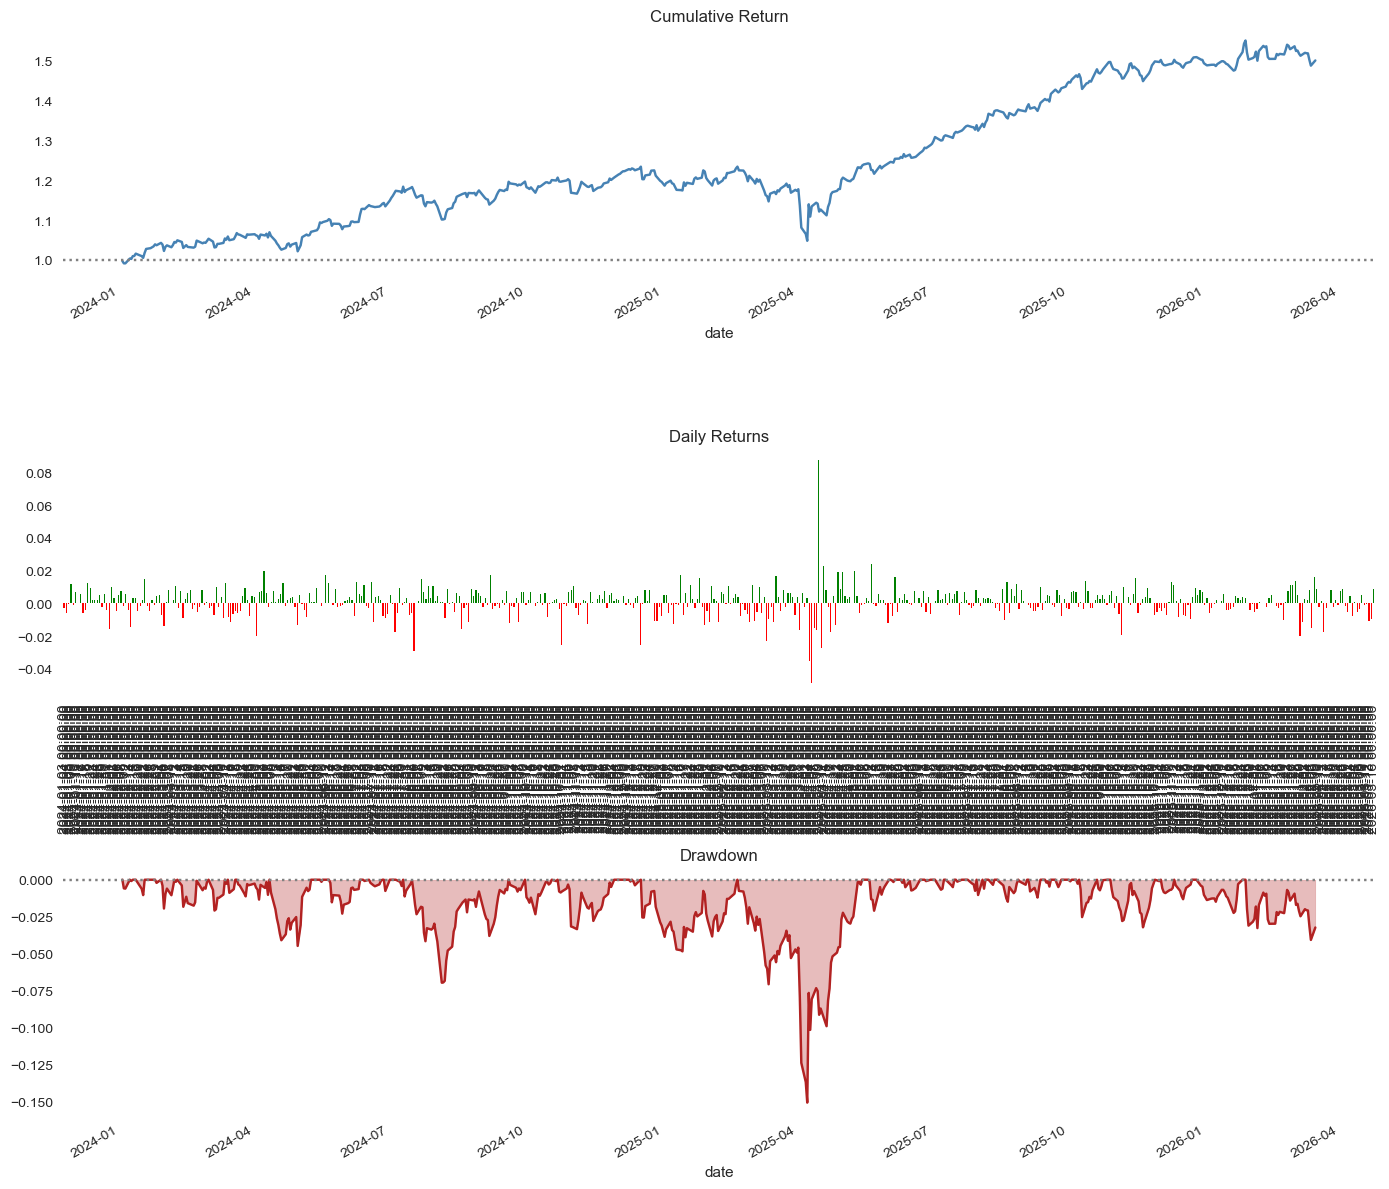

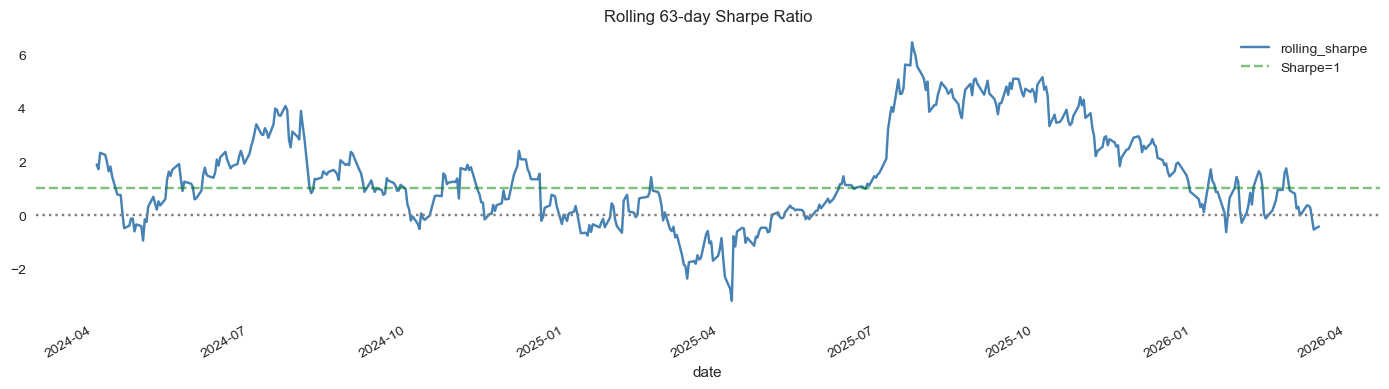

In [8]:
# Run the full pipeline (fetches live data)
from src.pipelines.run_pipeline import run_pipeline
out = run_pipeline(use_warehouse=False)

In [9]:
port_returns = out['portfolio_returns']
cum_returns = out['cumulative_returns']
perf = out['perf_metrics']

print('=== Performance ===')
for k, v in perf.items():
    print(f'  {k:35s}: {v:.4f}')

=== Performance ===
  cumulative_return                  : 0.5012
  annualized_return                  : 0.2042
  annualized_volatility              : 0.1358
  sharpe_ratio                       : 1.0769
  sortino_ratio                      : 1.1437
  calmar_ratio                       : 1.3525
  hit_ratio                          : 0.5608
  best_day_return                    : 0.0875
  worst_day_return                   : -0.0486
  total_trading_days                 : 551.0000
  risk_free_rate_annual              : 0.0500


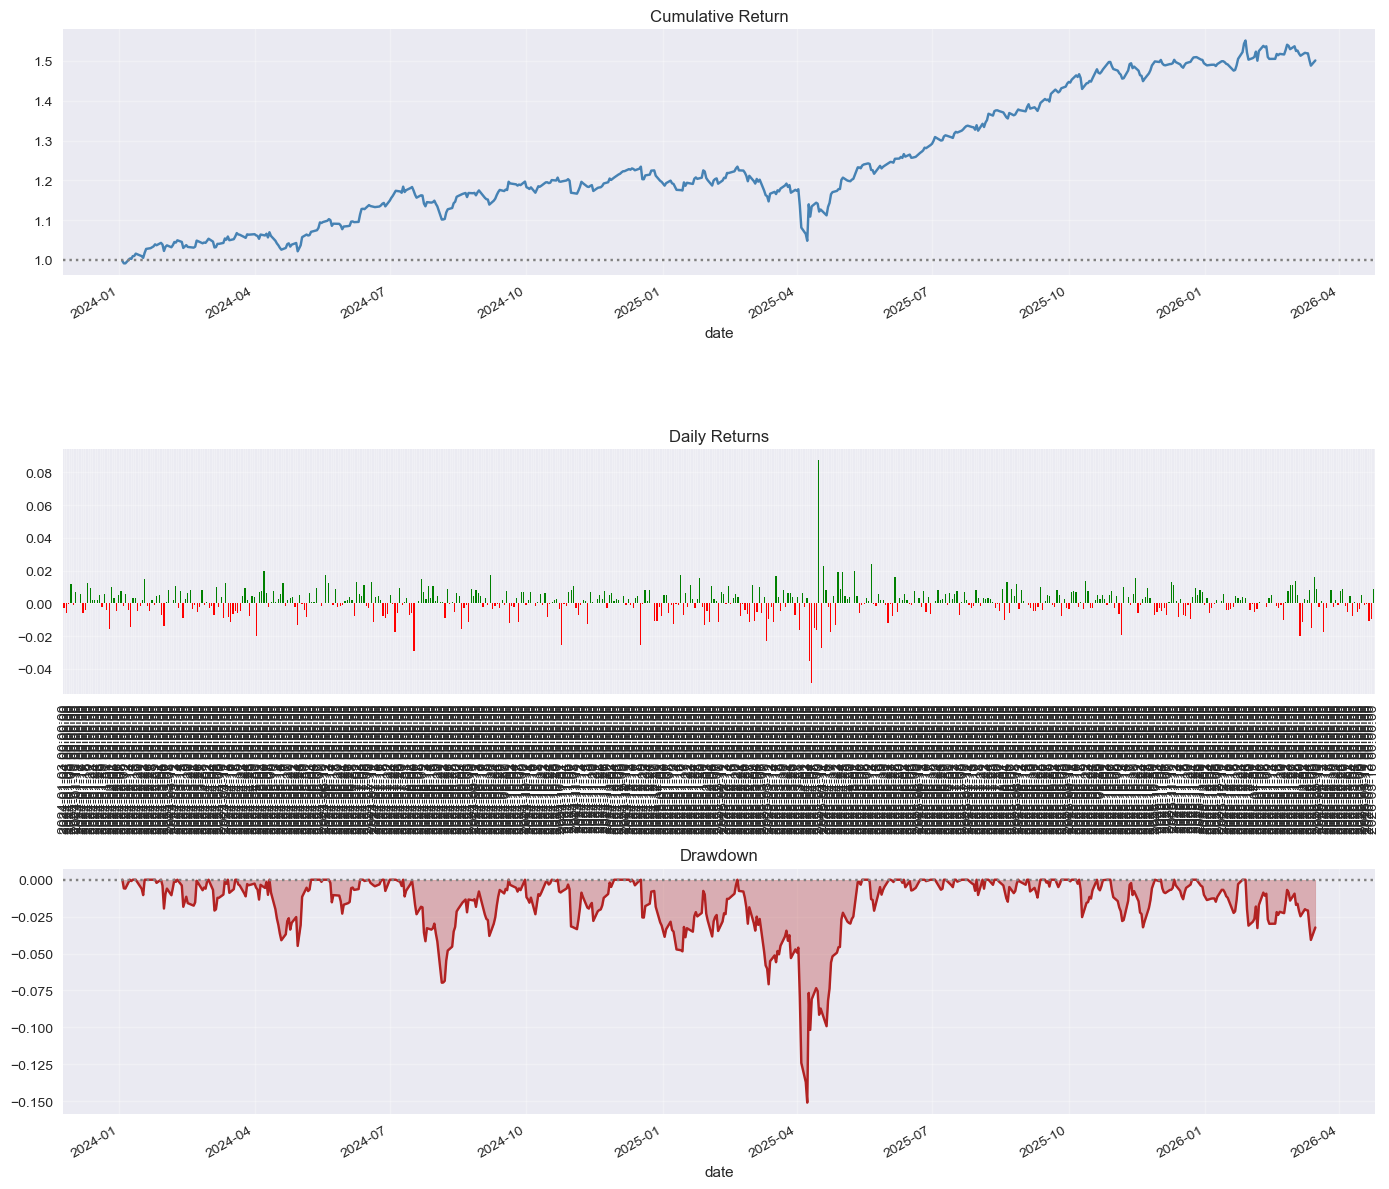

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Equity curve
(1 + port_returns).cumprod().plot(ax=axes[0], color='steelblue', title='Cumulative Return')
axes[0].axhline(1, linestyle=':', color='gray')

# Daily returns bar
port_returns.plot(ax=axes[1], kind='bar', color=['green' if r>=0 else 'red' for r in port_returns], title='Daily Returns')
axes[1].set_xlabel('')

# Drawdown
from src.analytics.risk import compute_drawdown_series
dd = compute_drawdown_series(port_returns).fillna(0)
dd.plot(ax=axes[2], color="firebrick", title="Drawdown")
axes[2].fill_between(dd.index, dd.values, 0, alpha=0.3, color="firebrick")
axes[2].axhline(0, linestyle=":", color="gray")

plt.tight_layout()
plt.show()

In [11]:
risk = out['risk_metrics']
print('=== Risk Metrics ===')
for k, v in risk.items():
    print(f'  {k:40s}: {v:.4f}')

=== Risk Metrics ===
  daily_volatility                        : 0.0086
  annualized_volatility                   : 0.1358
  downside_deviation_annual               : 0.0999
  max_drawdown                            : -0.1510
  average_drawdown                        : -0.0196
  var_95_1d                               : 0.0117
  cvar_95_1d                              : 0.0191
  return_skewness                         : 1.1405
  return_excess_kurtosis                  : 21.2287
  var_confidence                          : 0.9500


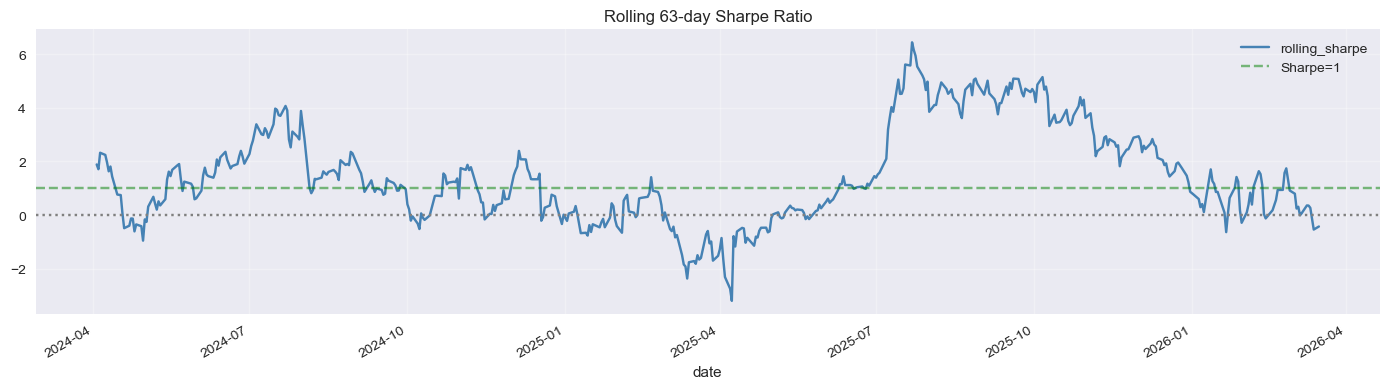

In [12]:
# Rolling Sharpe
from src.analytics.performance import compute_rolling_metrics
rolling = compute_rolling_metrics(port_returns)

fig, ax = plt.subplots(figsize=(14, 4))
rolling['rolling_sharpe'].plot(ax=ax, color='steelblue', title='Rolling 63-day Sharpe Ratio')
ax.axhline(0, linestyle=':', color='gray')
ax.axhline(1, linestyle='--', color='green', alpha=0.5, label='Sharpe=1')
ax.legend()
plt.tight_layout()
plt.show()